In [1]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

with open('squad_v2.0.json', 'r') as f:
    data = json.load(f)

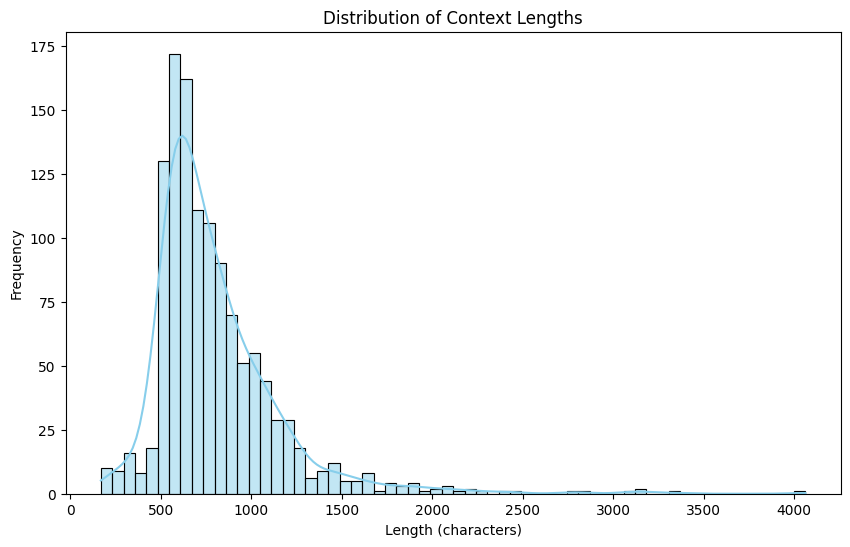

Excluded Examples: 47 (3.9%)


In [2]:
# Extract the lengths
lengths = [len(par['context']) for topic in data['data'] for par in topic['paragraphs']]

# Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(lengths, kde=True, color='skyblue')

# Add labels and title
plt.title('Distribution of Context Lengths')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')

plt.show()

max_len = 1500
no_over_max_len = sum([l > max_len for l in lengths])
print(f"Excluded Examples: {no_over_max_len} ({round(no_over_max_len/len(lengths)*100,2)}%)")

In [3]:
samples = []

for topic in data['data']:

    for paragraph in topic['paragraphs']:
        context = paragraph['context']
        if len(paragraph['context']) > max_len:
            continue

        for qa_pair in paragraph['qas']:
            if qa_pair['is_impossible']: continue

            id = qa_pair['id']

            # process questions
            question = qa_pair['question']
            question = question.strip(' ./!')
            if question[-1] != '?':
                question += '?'

            # process answers
            answers = [answer['text'] for answer in qa_pair['answers']]
            answer_parts = answers[0].split()

            if any([answers[0] != answer for answer in answers[1:]]): continue
            if answer_parts[0] in ['the', 'a', 'an']: continue
            if len(answer_parts) > 2: continue

            answer = answers[0].strip()
            answer = answer[0].upper() + answer[1:]

            # answer span
            answer_start = qa_pair['answers'][0]['answer_start']
            answer_span = (answer_start, answer_start + len(answer))
            assert context[answer_span[0]: answer_span[1]] == answers[0]

            

            samples.append({
                "id": id,
                "question": question,
                "answer": answer,
                "answer_span": answer_span,
                "context": context
            })
        
with open('../squad_v2.0.json', 'w') as f:
    json.dump(samples, f, indent=2)